In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model_no_previous, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-09-14 18:26:09.975467: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-09-14 18:26:10.180608: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-09-14 18:26:10.180638: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-09-14 18:26:10.182440: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-09-14 18:26:10.271424: I tensorflow/core/platform/cpu_feature_g

In [2]:
COHERENCE_LOSS = l1_loss
MAIN_LOSS = l1_loss
LANDMARKS_LOSS = pairwise_loss
LANDMARKS_COHERENCE_LOSS = pairwise_loss
INTERPOLATION_FRAMES_LOSS = l1_loss
INTERPOLATION_LANDMARKS_LOSS = None

# Dimensions
r = 256
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68
BATCH_SIZE = 10
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 15
N_TESTING_FRAMES = 42000

LAMBDA_MAIN_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = None
LAMBDA_INTERPOLATION_FRAMES_LOSS = 200
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
OUPUT_PATH  = APP_PATH / 'output'

default_dimension = "mug128"

In [3]:
id_string = f"b{BATCH_SIZE}_r{r}_"
if MAIN_LOSS:
    id_string += f"f1_{MAIN_LOSS.__name__}_{LAMBDA_MAIN_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f6_l1_loss_200'

In [4]:
log_dir=APP_PATH / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

In [5]:
OUTPUT_MEDIA_FOLDER = OUPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

## Load the dataset

In [6]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

In [7]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [8]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2023-09-14 18:26:15.949282: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-14 18:26:15.967731: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-09-14 18:26:15.967852: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

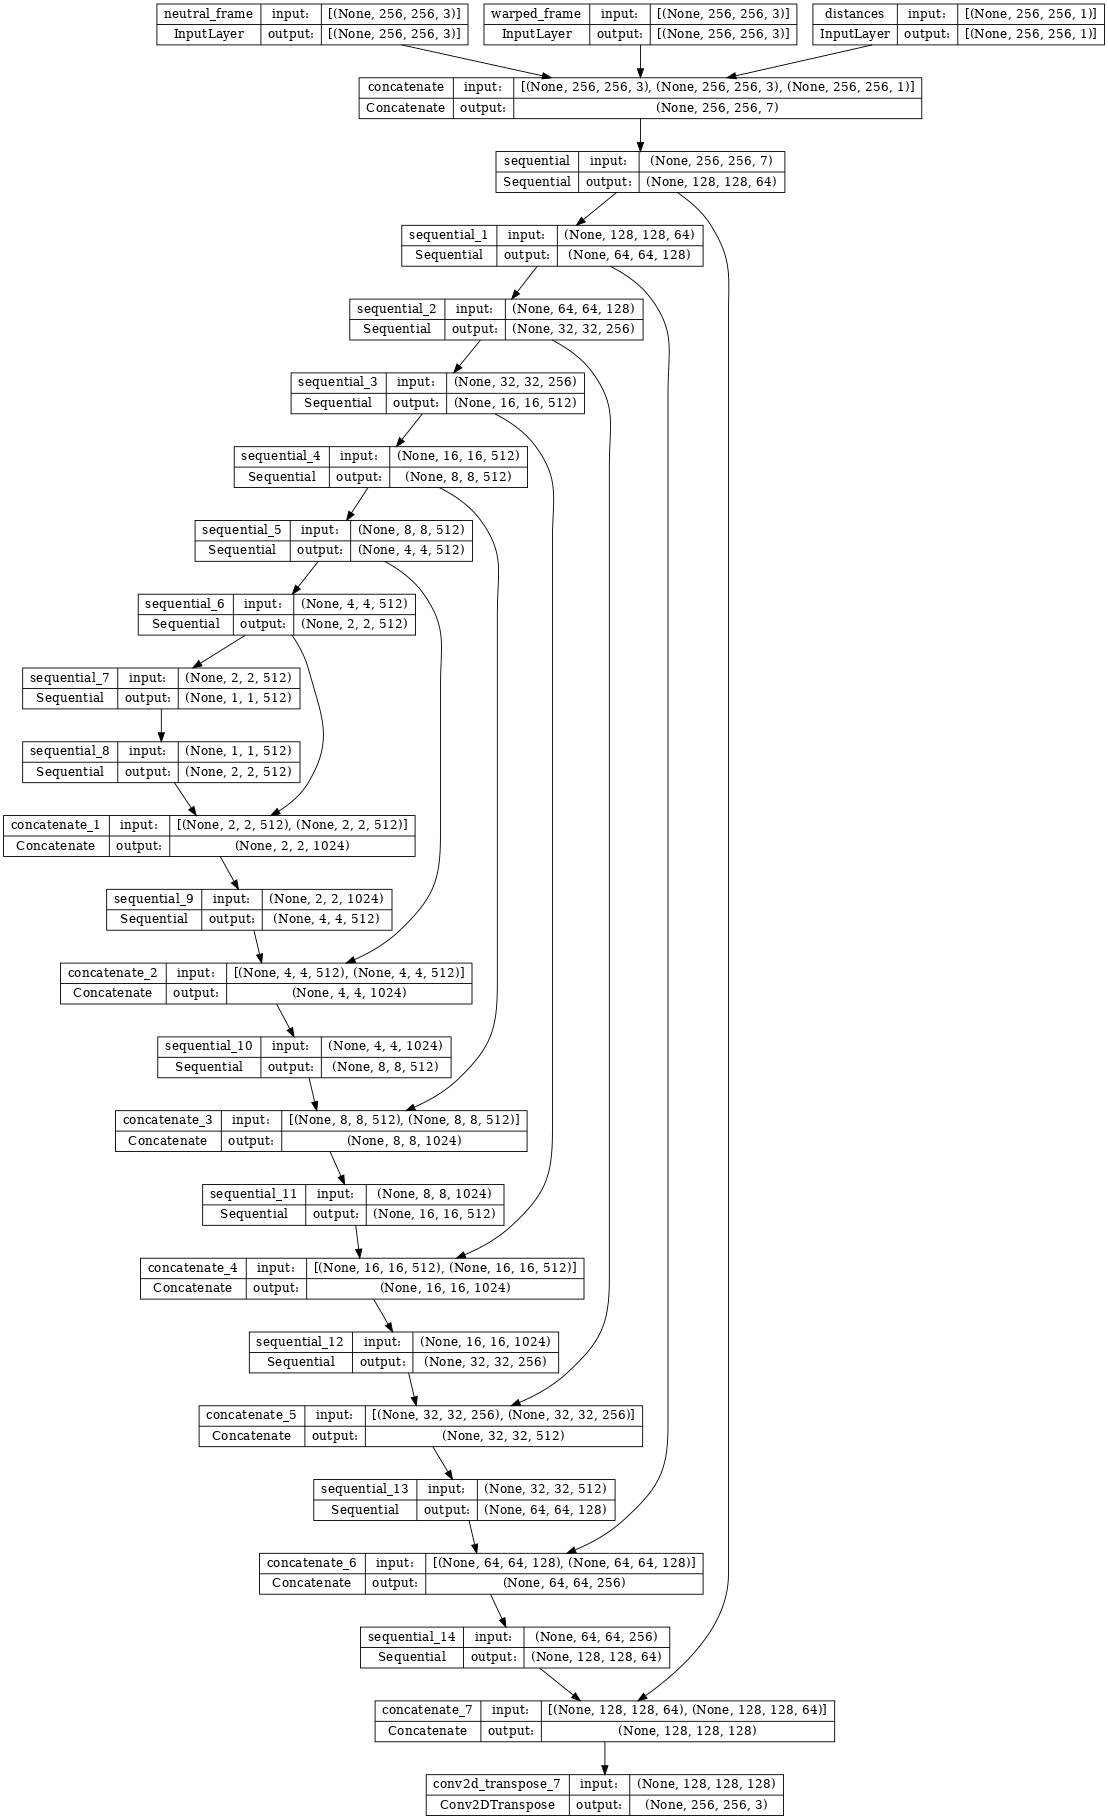

In [9]:
generator = get_generator_model_no_previous(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))

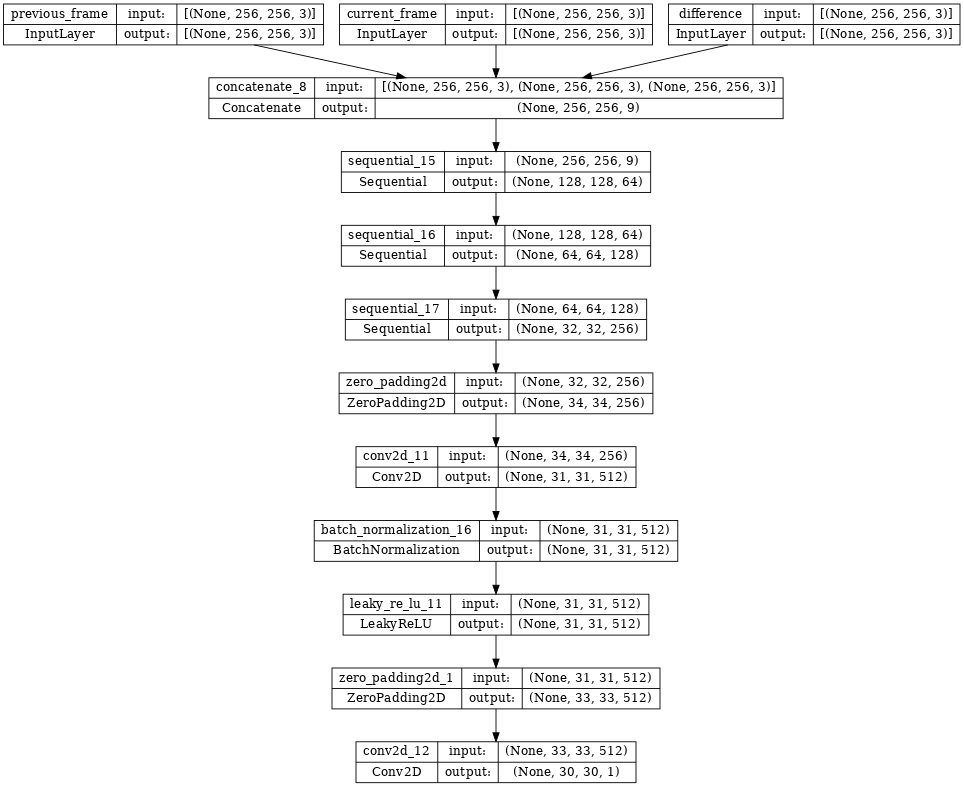

In [10]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))

In [11]:
generator_loss = GeneratorLoss(
    main_loss_function=MAIN_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    coherence_loss_function=COHERENCE_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)
                    

In [12]:
discriminator_loss = DiscriminatorLoss()

In [13]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [14]:
BASE_DIR = OUPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [15]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [16]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss, gen_vgg_loss, gen_styles_loss, gen_interpolation_frame_loss, gen_interpolation_landmarks_loss = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          if generator_loss.main_loss_function:
            tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=step)
          if generator_loss.coherence_loss_function:
            tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=step)
          if generator_loss.landmarks_loss_function:
            tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=step)
          if generator_loss.landmarks_coherence_loss_function:
            tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=step)
          if generator_loss.lambda_vgg_loss:
            tf.summary.scalar(f'gen_vgg_loss', gen_vgg_loss, step=step)
          if generator_loss.lambda_styles_loss:
            tf.summary.scalar(f'gen_styles_loss', gen_styles_loss, step=step)
          if generator_loss.interpolation_frames_loss_function:
            tf.summary.scalar(f'gen_interpolation_frame_loss', gen_interpolation_frame_loss, step=step)
          if generator_loss.interpolation_landmarks_loss_function:
            tf.summary.scalar(f'gen_interpolation_landmarks_loss', gen_interpolation_landmarks_loss, step=step)
          
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [17]:
tf.profiler.experimental.start(str(log_dir))

2023-09-14 18:26:16.803053: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-09-14 18:26:16.803078: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2023-09-14 18:26:16.803117: I tensorflow/compiler/xla/backends/profiler/gpu/cupti_tracer.cc:1694] Profiler found 1 GPUs


In [18]:
train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


 22%|##2       | 2205/10000 [59:27<2:29:28,  1.15s/it]

Input Sequence


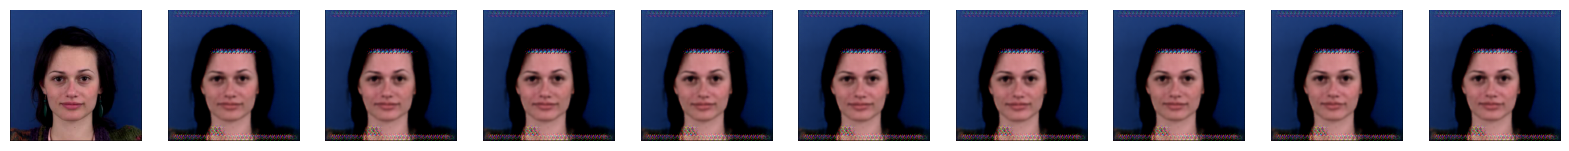

Ground Truth


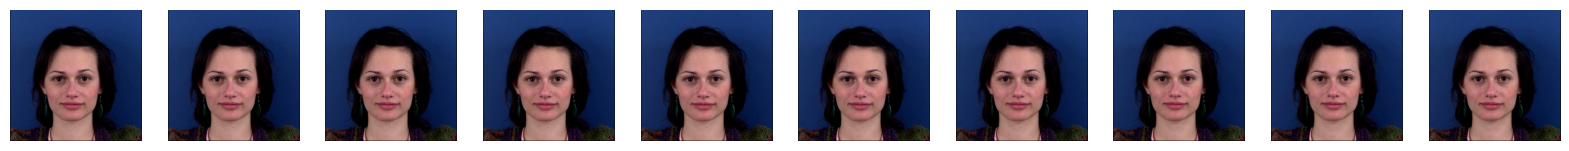

Predicted Sequence


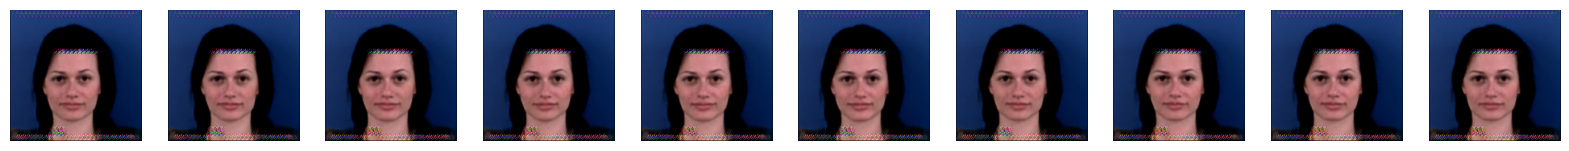

In [ ]:
fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  previously_generated, generated_frames, samples_target = test_generator.generate_next_batch()
  clear_output(wait=True)
  plot_results(samples_target, previously_generated, generated_frames)

In [ ]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

scores_path = f"{log_dir}/metrics.csv"
# df = pd.read_csv(scores_path, index_col=0)  
scores = compute_scores()
df = pd.DataFrame(scores)

In [ ]:
df.to_csv(scores_path)
print(df)

In [ ]:
print(df.mean())

In [ ]:
print(df.std())

# coherence measures

In [ ]:
from data_generator import PreprocessedDataGenerator
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)

In [ ]:
def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/diff_metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_diff_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

scores_path = f"{log_dir}/diff_metrics.csv"
# df = pd.read_csv(scores_path, index_col=0)  
scores = compute_scores()
df = pd.DataFrame(scores)

In [ ]:
print(df.mean())

In [ ]:
print(df.std())

In [ ]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
for i in range(0,10):
  clear_output(wait=True)
  test_generator.next_plot()